# DSE 200 FINAL PROJECT
## Fall 2025
### Due Date: November 21th, 2025

This project is culmination of all you’ve learned in this course! You should expect to spend <b>24-32 total hours</b> on the project. Be sure to read all of the items below before starting.

There are a number of steps outlined below, but is critical that you do not view this as an entirely linear process.  Remember that the science component in data science is the creation of a hypothesis based on exploration and testing of that hypothesis through analysis.  You may need to go through many of these steps multiple times before you arrive at meaningful hypothesis or conclusions.

## Step 1: Find a dataset or datasets

Based on your interest, identify a dataset which you will want to examine.  You will find a starting point for where you can find open datasets at the end of this notebook, but feel free to use other datasets you have access to and can publicly share results about.


This step may take some time, as you’ll likely look at a number of datasets before you find one (or more) which holds promising data for the kinds of questions you want to ask. You are expected to use at least two interconnected datasets, e.g., two tables in one database or a combination of datasets which you can merge in some meaningful way.


In [31]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn kagglehub

In [32]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from transformers import pipeline
from scipy import stats

In [33]:
# EXPLAIN AND INGEST YOUR DATASET IN THIS SECTION
# The Tesla stock dataset daily historical stock prices for Tesla, Inc. (TSLA). The data was sourced from Yahoo Finance and covers a significant period spanning from Tesla’s initial public offering (IPO) to the Nov 2025.
# The dataset includes critical trading metrics for each market day, such as the opening price, highest and lowest prices of the day, closing price, adjusted closing price (accounting for dividends and splits), and total trading volume.

# Download latest version
path = kagglehub.dataset_download("adilshamim8/tesla-stock-price-history")

print("Path to dataset files:", path)

# Tesla_stock_data.csv
stock_df = pd.read_csv(path + "/Tesla_stock_data.csv")
print(stock_df.shape)
stock_df.head()

Using Colab cache for faster access to the 'tesla-stock-price-history' dataset.
Path to dataset files: /kaggle/input/tesla-stock-price-history
(3876, 6)


,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [34]:
# EXPLAIN AND INGEST YOUR DATASET IN THIS SECTION
# Elon Musk Tweets datasets contain (1) Elon Musk's tweets from his official account (@elonmusk) from 2010 through April 13, 2025; (2) The original tweets that Elon Musk quote-tweeted to his official account (@elonmusk) from 2010 through April 13, 2025.

# Download latest version
path = kagglehub.dataset_download("dadalyndell/elon-musk-tweets-2010-to-2025-march")

print("Path to dataset files:", path)

## Limit tweet data to stock df timeframe

# all_musk_posts.csv
tweets_df = pd.read_csv(path + "/all_musk_posts.csv")
print(tweets_df.shape)
tweets_df.head()


Using Colab cache for faster access to the 'elon-musk-tweets-2010-to-2025-march' dataset.
Path to dataset files: /kaggle/input/elon-musk-tweets-2010-to-2025-march
(55099, 24)


/tmp/ipython-input-2853558576.py:12: DtypeWarning: Columns (11,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets_df = pd.read_csv(path + "/all_musk_posts.csv")


,id,url,twitterUrl,fullText,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,...,inReplyToUserId,inReplyToUsername,isPinned,isRetweet,isQuote,isConversationControlled,possiblySensitive,quoteId,quote,retweet
0,1655159652990976000,https://x.com/elonmusk/status/1655159652990976000,https://twitter.com/elonmusk/status/1655159652...,RT @einarvollset: I read @paulg’s “How to Mak...,NaN,NaN,NaN,NaN,NaN,2023-05-07 10:36:27+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1657261624867299339,https://x.com/elonmusk/status/1657261624867299339,https://twitter.com/elonmusk/status/1657261624...,https://t.co/Zjn6r15lrR,NaN,NaN,NaN,NaN,NaN,2023-05-13 05:48:56+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1623774484795920384,https://x.com/elonmusk/status/1623774484795920384,https://twitter.com/elonmusk/status/1623774484...,RT @BillyM2k: dude bookmarks are an awesome tw...,NaN,NaN,NaN,NaN,NaN,2023-02-09 20:03:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1656900119202254854,https://x.com/elonmusk/status/1656900119202254854,https://twitter.com/elonmusk/status/1656900119...,Event Horizon Balance Beam,NaN,NaN,NaN,NaN,NaN,2023-05-12 05:52:26+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1616531874763116544,https://x.com/elonmusk/status/1616531874763116544,https://twitter.com/elonmusk/status/1616531874...,RT @BillyM2k: @elonmusk oh that’s actually pre...,NaN,NaN,NaN,NaN,NaN,2023-01-20 20:23:27+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# musk_quote_tweets.csv
quote_tweets_df = pd.read_csv(path + "/musk_quote_tweets.csv")
print(quote_tweets_df.shape)
quote_tweets_df.head()

(7273, 21)


,orig_tweet_id,orig_tweet_created_at,orig_tweet_text,orig_tweet_url,orig_tweet_twitter_url,orig_tweet_username,orig_tweet_retweet_count,orig_tweet_reply_count,orig_tweet_like_count,orig_tweet_quote_count,...,orig_tweet_bookmark_count,musk_tweet_id,musk_quote_tweet,musk_quote_retweet_count,musk_quote_reply_count,musk_quote_like_count,musk_quote_quote_count,musk_quote_view_count,musk_quote_bookmark_count,musk_quote_created_at
0,1655977349530243074,2023-05-09 16:45:41+00:00,Hot take:\n\n@Twitter can become the world's n...,https://x.com/GuyDealership/status/16559773495...,https://twitter.com/GuyDealership/status/16559...,GuyDealership,632,497,7730,123,...,387,1655978502187778073,Yup,3255,3747,39533,225,11392206.0,281,2023-05-09 16:50:16+00:00
1,1655968201422012418,2023-05-09 16:09:20+00:00,If Legacy Media is going to shove bigotry porn...,https://x.com/TheRabbitHole84/status/165596820...,https://twitter.com/TheRabbitHole84/status/165...,TheRabbitHole84,1409,412,5328,264,...,633,1655968899903418373,Massive public manipulation,9811,2694,49528,534,14404853.0,1241,2023-05-09 16:12:06+00:00
2,1647327385342320640,2023-04-15 19:53:49+00:00,Starlink provides internet to the most remote ...,https://x.com/teslaownersSV/status/16473273853...,https://twitter.com/teslaownersSV/status/16473...,teslaownersSV,1253,800,8472,175,...,173,1647339741610926080,💯,8257,4793,106036,376,18520248.0,366,2023-04-15 20:42:55+00:00
3,1646226917387796491,2023-04-12 19:00:57+00:00,National Public Radio Denies Being National Or...,https://x.com/TheBabylonBee/status/16462269173...,https://twitter.com/TheBabylonBee/status/16462...,TheBabylonBee,4781,701,37752,442,...,167,1646228474628280326,🤣🤣,10198,5076,108462,430,16690340.0,340,2023-04-12 19:07:08+00:00
4,1640016339011076097,2023-03-26 15:42:19+00:00,Arthur C. Clarke about the future of AI. \n—21...,https://x.com/Rainmaker1973/status/16400163390...,https://twitter.com/Rainmaker1973/status/16400...,Rainmaker1973,5409,737,20773,814,...,3333,1640171198091866114,Prescient,9193,5118,56272,572,25169601.0,3792,2023-03-27 01:57:41+00:00


In [36]:
# Final Project Phase 2: Incorporate Tesla news DF into controversial tweet DF to see if there is any correlation with news stories on days where "controversial" tweets from Elon potentially caused tesla stock to rise that day.

# Load the Tesla news dataset - Upload the csv file below (located in project zip folder) into Collab file explorer
news_df = pd.read_csv('teslarati_all.csv')

print(f"News data shape: {news_df.shape}")
print(news_df.head())

print("\nColumn names:")
print(news_df.columns.tolist())

News data shape: (24490, 3)
                                               title  \
0  Tesla CEO Elon Musk sends final warning to Bil...   
1  Tesla rolls out most aggressive Model Y lease ...   
2  Tesla is looking to phase out China-made parts...   
3  Tesla owners propose interesting theory about ...   
4  Ron Baron states Tesla and SpaceX are lifetime...   

                         published  \
0  Sun, 16 Nov 2025 19:41:44 +0000   
1  Sat, 15 Nov 2025 18:03:54 +0000   
2  Sat, 15 Nov 2025 17:42:23 +0000   
3  Fri, 14 Nov 2025 16:32:40 +0000   
4  Fri, 14 Nov 2025 15:16:22 +0000   

                                             summary  
0  <p>"If Gates hasn’t fully closed out the crazy...  
1  <p>With the promotion in place, customers woul...  
2  <p>Tesla has reportedly swapped out several Ch...  
3  <p>"100%. It’s needed for sales because for ma...  
4  <p>Baron, one of Tesla’s longest-standing bull...  

Column names:
['title', 'published', 'summary']


## Step 2: Explore the datasets

In this step, you should explore what is present in the data and how the data is organized. You’ll need to determine what common features allow you to merge the datasets.  

You are expected to answer the following questions using the _pandas_ library and markdown cells to describe your actions:

* Are there quality issues in the dataset (noisy, missing data, etc.)?
* What will you need to do to clean and/or transform the raw data for analysis?

You are also expected to use the _matplotlib_ library to visually explore the datasets and explain your findings, specifically,

* How are the data distributed?
* What are some common trends?
* What are the relationships between variables in your datasets?

In [37]:
print(tweets_df.columns.tolist())
print(quote_tweets_df.columns.tolist())

['id', 'url', 'twitterUrl', 'fullText', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'createdAt', 'bookmarkCount', 'isReply', 'inReplyToId', 'conversationId', 'inReplyToUserId', 'inReplyToUsername', 'isPinned', 'isRetweet', 'isQuote', 'isConversationControlled', 'possiblySensitive', 'quoteId', 'quote', 'retweet']
['orig_tweet_id', 'orig_tweet_created_at', 'orig_tweet_text', 'orig_tweet_url', 'orig_tweet_twitter_url', 'orig_tweet_username', 'orig_tweet_retweet_count', 'orig_tweet_reply_count', 'orig_tweet_like_count', 'orig_tweet_quote_count', 'orig_tweet_view_count', 'orig_tweet_bookmark_count', 'musk_tweet_id', 'musk_quote_tweet', 'musk_quote_retweet_count', 'musk_quote_reply_count', 'musk_quote_like_count', 'musk_quote_quote_count', 'musk_quote_view_count', 'musk_quote_bookmark_count', 'musk_quote_created_at']


In [38]:
#PERFORM AND EXPLAIN YOUR EXPLORATORY ANALYSIS IN THIS SECTION

# Check for missing values
print("Missing Values in Stock Data")
print(stock_df.isnull().sum())

print("\nMissing Values in Tweet Data")
print(tweets_df.isnull().sum())

print("\nMissing Values in Quote Tweet Data")
print(quote_tweets_df.isnull().sum())

# Get data types
print("\nStock Data Types")
print(stock_df.dtypes)

print("\nTweet Data Types")
print(tweets_df.dtypes)

print("\nQuote Tweet Data Types")
print(quote_tweets_df.dtypes)

# Convert dates to datetime format
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.strftime('%Y-%m-%d')

tweets_df['createdAt'] = pd.to_datetime(tweets_df['createdAt'])
tweets_df['date_only'] = tweets_df['createdAt'].dt.strftime('%Y-%m-%d')

quote_tweets_df['musk_quote_created_at'] = pd.to_datetime(quote_tweets_df['musk_quote_created_at'])
quote_tweets_df['date_only'] =quote_tweets_df['musk_quote_created_at'].dt.strftime('%Y-%m-%d')

# Sort by date
stock_df = stock_df.sort_values('Date')
tweets_df = tweets_df.sort_values('createdAt')
quote_tweets_df = quote_tweets_df.sort_values('musk_quote_created_at')

# Calculate daily returns (percentage change in stock price)
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

# Basic statistics
print("\nStock Price Statistics")
print(stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

print("\nDaily Return Statistics")
print(f"Average daily return: {stock_df['daily_return'].mean():.2f}%")
print(f"Biggest gain: {stock_df['daily_return'].max():.2f}%")
print(f"Biggest loss: {stock_df['daily_return'].min():.2f}%")

Missing Values in Stock Data
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Missing Values in Tweet Data
id                              0
url                             0
twitterUrl                      0
fullText                        0
retweetCount                   90
replyCount                    802
likeCount                      90
quoteCount                    828
viewCount                   20644
createdAt                       0
bookmarkCount                 828
isReply                       828
inReplyToId                 15602
conversationId                802
inReplyToUserId             15578
inReplyToUsername           15578
isPinned                      828
isRetweet                      90
isQuote                       116
isConversationControlled      828
possiblySensitive           50178
quoteId                     47558
quote                       47826
retweet                     54007
dtype: int64

Missing Values in Quote Tw

####### Data Exploration Questions ############

# (1) Are there quality issues in the dataset (noisy, missing data, etc.)?

The stock data is very clean with no missing values for all 3,861 trading days. That makes it ideal for time-series analysis which is ideal since I will be correlating it with the tweet data.

The tweet data has quite a few data quality challenges. Of the 55,099 original tweets, there were a lot of missing values in the engagement metrics I chose. For example the viewCount field has over 20k missing values (37% of the dataset), bookmarkCount and several metadata fields have 828 missing values each, and the replyCount field shows 802 missing values. This suggests that Twitter's API didn't return these metrics for older tweets as they most likely weren't available at that time. The high number of missing values in fields like possiblySensitive (50,178 missing) and retweet (54,007 missing) indicate these are fields that don't always populate, only under specific conditions.
The quote tweet dataset is more complete, with only around 500 missing values for each tweet dataset.

# (2) What will you need to do to clean and/or transform the raw data for analysis? (Some of this is done in below code blocks)

*   Standardize dates - Converted all date fields from strings to datetime format, then created a standardized date_only field as 'YYYY-MM-DD' strings. This allows me to merge datasets and handles weekends/holidays when markets are closed. My functions return 0 for non-trading days rather than errors.
*   Consolidate tweet datasets - The original tweet dataset included quote tweets too, so I filtered those out as not to duplicate those rows of data in my merged tweet dataset.
*   Feature engineering - Created stock metrics to measure performance on tweet dates. Built custom functions that match tweets to stock data while handling non-trading days.
*   Missing data strategy - For engagement metrics with a lot of missing data (views, bookmarks), I'll run a separate analysis including and excluding these fields.




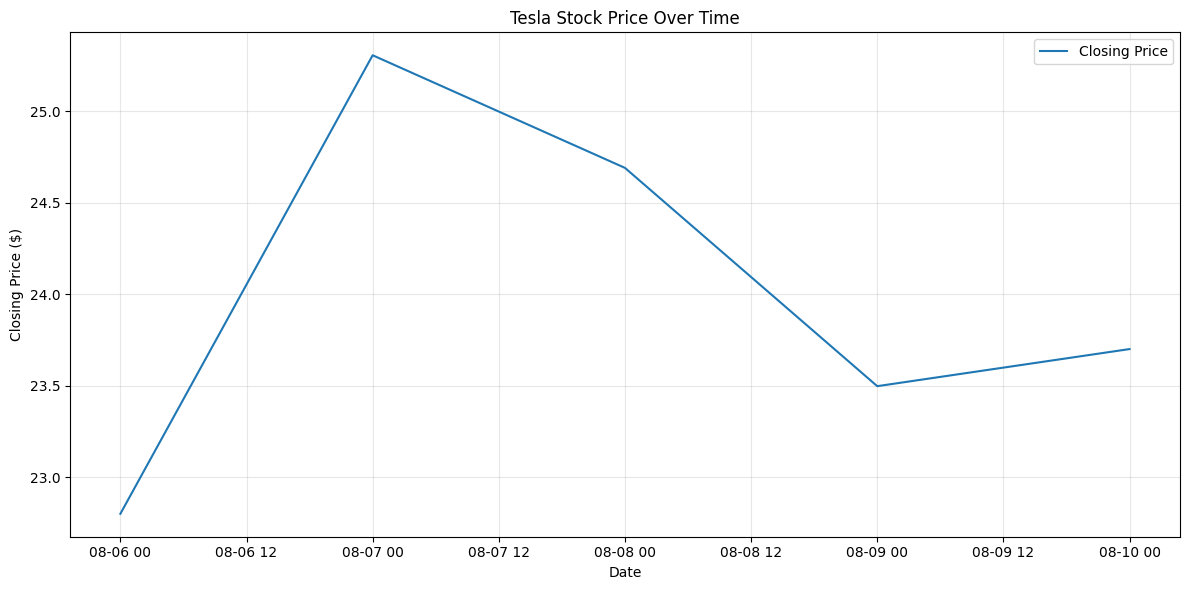

In [39]:
# Narrow down x axis to investigate spikes / High profile events
mask = (stock_df['Date'] >= '2018-08-06') & (stock_df['Date'] <= '2018-08-10')
df_filtered = stock_df.loc[mask]

plt.figure(figsize=(12, 6))
plt.plot(df_filtered['Date'], df_filtered['Close'], label='Closing Price')
plt.title('Tesla Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


In [40]:
stockDF = stock_df

#intakes String for delta
def deltaPriceDay(date):

  if type(date) != str:
    date = str(date.date())

  if '/' in date:
    date = pd.to_datetime(date).strftime("%Y-%m-%d")



  x = stockDF[stockDF['date_only'] == date]

  if len(x) < 1:

    return 0

  deltaDay = x['Close'] - x['Open']

  return float(deltaDay.iloc[0])


def deltaHL(date):

  if type(date) != str:
    date = str(date)


  x = stockDF[stockDF['date_only'] == date]

  if len(x) < 1:
    return 0


  deltaDay = x['High'] - x['Low']
  return float(deltaDay.iloc[0])

# Get next trading day's return (percentage change)
def nextDayReturn(date):
  if type(date) != str:
    date = str(date)

  # Find current day
  current = stockDF[stockDF['date_only'] == date]

  if len(current) < 1:
    return 0

  # Get index of current day
  idx = current.index[0]

  # Check if next day exists
  if idx + 1 >= len(stockDF):
    return 0

  # Calculate percentage return from current close to next close
  current_close = stockDF.loc[idx, 'Close']
  next_close = stockDF.loc[idx + 1, 'Close']

  return ((next_close - current_close) / current_close) * 100


#intakes string
def deltaNexDay(dt):
  date = pd.to_datetime(dt)
  mask = (stockDF['Date'].astype('datetime64[ns]') >= date) & (stockDF['Date'].astype('datetime64[ns]') <= date + pd.Timedelta(days=1))

  if len(stockDF[mask]) < 2:
    return 0

  return stockDF[mask].iloc[1]['Close'] - stockDF[mask].iloc[0]['Open']


#intakes string
def deltaVMeanWeek(dt):
  date = pd.to_datetime(dt)
  mask = (stockDF['Date'].astype('datetime64[ns]') >= date) & (stockDF['Date'].astype('datetime64[ns]') <= date + pd.Timedelta(days=7))
  mean = stockDF[mask]['Volume'].mean()
  std = stockDF[mask]['Volume'].std()
  if len(stockDF[mask]) < 2:
    return 0

  return (stockDF[mask].iloc[0]['Volume'] - mean) / std # z score

print(f"deltaPriceDay: {deltaPriceDay('2025-04-10')}%")
print(f"Next day return: {nextDayReturn('2025-04-10')}%")

deltaPriceDay: -7.600006103515597%
Next day return: -0.03565623615965363%


In [41]:
# Joining Tweet & Quote Tweet Dataframes
print(f"Main Tweet: {len(tweets_df)} rows")
print(f"Quote Tweets: {len(quote_tweets_df)} rows")

# Filter out quote tweets from main dataset since they're already contained in quote_tweets_df
main_tweets_only = tweets_df[tweets_df['isQuote'] == False].copy()
print(f"Main tweets (w/out quote tweets): {len(main_tweets_only)} rows")

# Create standardized dataframe for main tweets
main_tweets_standard = pd.DataFrame({
    'tweet_id': main_tweets_only['id'],
    'elon_text': main_tweets_only['fullText'],
    'retweets': main_tweets_only['retweetCount'],
    'replies': main_tweets_only['replyCount'],
    'likes': main_tweets_only['likeCount'],
    'quote_count': main_tweets_only['quoteCount'],
    'bookmarks': main_tweets_only['bookmarkCount'],
    'views': main_tweets_only['viewCount'],
    'created_at': pd.to_datetime(main_tweets_only['createdAt']),
    'date_only': main_tweets_only['date_only'],
    'tweet_type': 'main',
    'is_reply': main_tweets_only['isReply'],
    'is_pinned': main_tweets_only['isPinned'],
    'is_retweet': main_tweets_only['isRetweet'],
    'quoted_text': main_tweets_only['quote']
})

print(f"Standardized main tweets: {len(main_tweets_standard)} rows")

# Create standardized dataframe for quote tweets
quote_tweets_standard = pd.DataFrame({
    'tweet_id': quote_tweets_df['musk_tweet_id'],
    'elon_text': quote_tweets_df['musk_quote_tweet'],
    'retweets': quote_tweets_df['musk_quote_retweet_count'],
    'replies': quote_tweets_df['musk_quote_reply_count'],
    'likes': quote_tweets_df['musk_quote_like_count'],
    'quote_count': quote_tweets_df['musk_quote_quote_count'],
    'bookmarks': quote_tweets_df['musk_quote_bookmark_count'],
    'views': quote_tweets_df['musk_quote_view_count'],
    'created_at': pd.to_datetime(quote_tweets_df['musk_quote_created_at']),
    'date_only': quote_tweets_df['date_only'],
    'tweet_type': 'quote',
    'is_reply': False,  # Quote tweets are not replies
    'is_pinned': False,  # Quote tweets are not pinned
    'is_retweet': False,  # Quote tweets are not retweets
    'quoted_text': quote_tweets_df['orig_tweet_text']
})

print(f"Standardized quote tweets: {len(quote_tweets_standard)} rows")

# Merge all tweets into one DF
all_tweets_combined = pd.concat([main_tweets_standard, quote_tweets_standard], ignore_index=True)
all_tweets_combined = all_tweets_combined.merge(stock_df[['date_only', 'daily_return']], on='date_only', how='left')

all_tweets_combined['DeltaDay'] = all_tweets_combined['date_only'].astype('str').apply(deltaPriceDay)
all_tweets_combined['DeltaHighLow'] = all_tweets_combined['date_only'].astype('str').apply(deltaHL)
all_tweets_combined['next_day_return'] = all_tweets_combined['date_only'].astype('str').apply(nextDayReturn)

print(f"\nCombined dataset: {len(all_tweets_combined)} total tweets")
print(f"- Main tweets: {(all_tweets_combined['tweet_type'] == 'main').sum()}")
print(f"- Quote tweets: {(all_tweets_combined['tweet_type'] == 'quote').sum()}")

# Sort by date
all_tweets_combined = all_tweets_combined.sort_values('date_only',ascending=False)

all_tweets_combined.head()

Main Tweet: 55099 rows
Quote Tweets: 7273 rows
Main tweets (w/out quote tweets): 47687 rows
Standardized main tweets: 47687 rows
Standardized quote tweets: 7273 rows

Combined dataset: 54960 total tweets
- Main tweets: 47687
- Quote tweets: 7273


,tweet_id,elon_text,retweets,replies,likes,quote_count,bookmarks,views,created_at,date_only,tweet_type,is_reply,is_pinned,is_retweet,quoted_text,daily_return,DeltaDay,DeltaHighLow,next_day_return
54959,1911429071470293414,Starlink now in Somalia!,6310.0,4808.0,51382.0,691.0,1088.0,20256907.0,2025-04-13 14:39:37+00:00,2025-04-13,quote,False,False,False,SOMALIA GRANTS STARLINK LICENSE TO OPERATE NAT...,NaN,0.0,0.0,0.0
47679,1911425272953372813,RT @Tesla: No outages with Powerwall,948.0,437.0,5511.0,31.0,164.0,1973411.0,2025-04-13 14:24:32+00:00,2025-04-13,main,False,False,True,NaN,NaN,0.0,0.0,0.0
47686,1911532025233723740,Worth reading the book 1493,1317.0,2731.0,15579.0,196.0,2233.0,3135481.0,2025-04-13 21:28:44+00:00,2025-04-13,main,False,False,False,NaN,NaN,0.0,0.0,0.0
47685,1911531624417677356,RT @Tesla_AI: Giga Texas production now uses F...,914.0,387.0,5436.0,134.0,285.0,551510.0,2025-04-13 21:27:08+00:00,2025-04-13,main,False,False,True,NaN,NaN,0.0,0.0,0.0
47684,1911476643580854642,RT @howardlutnick: Calling U.S. factory worker...,1586.0,1298.0,8337.0,91.0,277.0,1006844.0,2025-04-13 17:48:40+00:00,2025-04-13,main,False,False,True,NaN,NaN,0.0,0.0,0.0


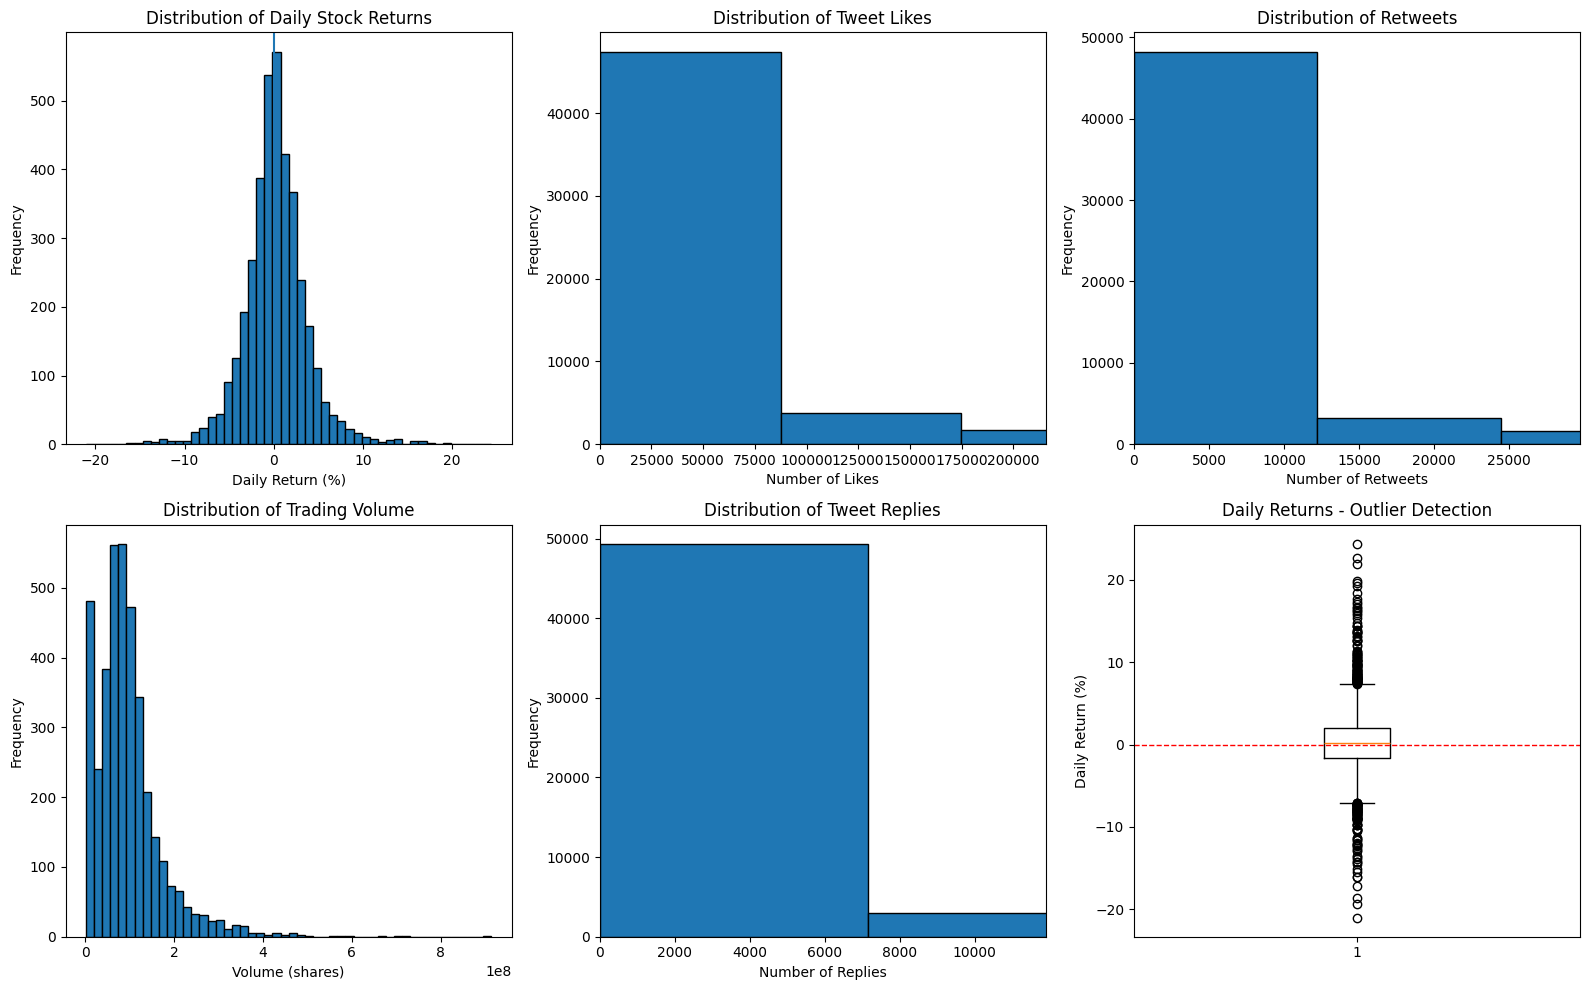

Stock Daily Returns:
count    3875.000000
mean        0.208162
std         3.646230
min       -21.062824
25%        -1.653773
50%         0.122060
75%         1.962551
max        24.395076
Name: daily_return, dtype: float64

Skewness: 0.37
Kurtosis: 4.89

Tweet Engagement Metrics:
              likes       retweets        replies    quote_count
count  5.496000e+04   54960.000000   54271.000000   54271.000000
mean   4.155329e+04    5153.631568    2376.133939     485.358442
std    1.065054e+05   14046.606729    6748.799234    3075.282293
min    0.000000e+00       0.000000       0.000000       0.000000
25%    1.351000e+03      80.000000     102.000000       8.000000
50%    4.196000e+03     276.000000     271.000000      29.000000
75%    2.858725e+04    2604.250000    1478.500000     205.000000
max    4.372808e+06  610842.000000  357538.000000  439431.000000


In [42]:
# DISTRIBUTION ANALYSIS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribution of daily returns
axes[0, 0].hist(stock_df['daily_return'].dropna(), bins=50, edgecolor='black')
axes[0, 0].axvline(x=0)
axes[0, 0].set_title('Distribution of Daily Stock Returns')
axes[0, 0].set_xlabel('Daily Return (%)')
axes[0, 0].set_ylabel('Frequency')

# Distribution of tweet likes
axes[0, 1].hist(all_tweets_combined['likes'].dropna(), bins=50, edgecolor='black')
axes[0, 1].set_title('Distribution of Tweet Likes')
axes[0, 1].set_xlabel('Number of Likes')
axes[0, 1].set_ylabel('Frequency')
# Remove extreme outliers for visibility
axes[0, 1].set_xlim(0, all_tweets_combined['likes'].quantile(0.95))

# Distribution of retweets
axes[0, 2].hist(all_tweets_combined['retweets'].dropna(), bins=50, edgecolor='black')
axes[0, 2].set_title('Distribution of Retweets')
axes[0, 2].set_xlabel('Number of Retweets')
axes[0, 2].set_ylabel('Frequency')
# Remove extreme outliers for visibility
axes[0, 2].set_xlim(0, all_tweets_combined['retweets'].quantile(0.95))

# Distribution of trading vlume
axes[1, 0].hist(stock_df['Volume'], bins=50, edgecolor='black')
axes[1, 0].set_title('Distribution of Trading Volume')
axes[1, 0].set_xlabel('Volume (shares)')
axes[1, 0].set_ylabel('Frequency')

# Distribution of tweet replies
axes[1, 1].hist(all_tweets_combined['replies'].dropna(), bins=50, edgecolor='black')
axes[1, 1].set_title('Distribution of Tweet Replies')
axes[1, 1].set_xlabel('Number of Replies')
axes[1, 1].set_ylabel('Frequency')
# Remove extreme outliers for visibility
axes[1, 1].set_xlim(0, all_tweets_combined['replies'].quantile(0.95))

# Boxplot of daily returns to show outliers
axes[1, 2].boxplot(stock_df['daily_return'].dropna(), vert=True)
axes[1, 2].set_title('Daily Returns - Outlier Detection')
axes[1, 2].set_ylabel('Daily Return (%)')
axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Print distribution statistics
print("Stock Daily Returns:")
print(stock_df['daily_return'].describe())
print(f"\nSkewness: {stock_df['daily_return'].skew():.2f}")
print(f"Kurtosis: {stock_df['daily_return'].kurtosis():.2f}")

print("\nTweet Engagement Metrics:")
print(all_tweets_combined[['likes', 'retweets', 'replies', 'quote_count']].describe())

# Distribution Analysis
*   Stock return distribution - Daily returns are normal with a slight positive skew. The high kurtosis and boxplot show fat tails which indicate very large movements occur more frequently than expected, with some large outliers present. This tells me that Tesla has sudden and large price swings.
*   Trading volume distribution - Heavily right-skewed with most days at 50-100 million shares but occasional spikes to >800 million shares. These massive volume days likely occur alongside major news events/controversies. Which could be potential tweet correlation candidates.
*   Tweet engagement distribution - All metrics (likes, retweets, replies) are extremely right-skewed. Median engagement is small (4,200 likes, 276 retweets), compared to the maximums which reach 4.4 million likes and 610,842 retweets. Most tweets get avg engagement while a small fraction go massively viral. I will need to account for this during for statistical modeling.

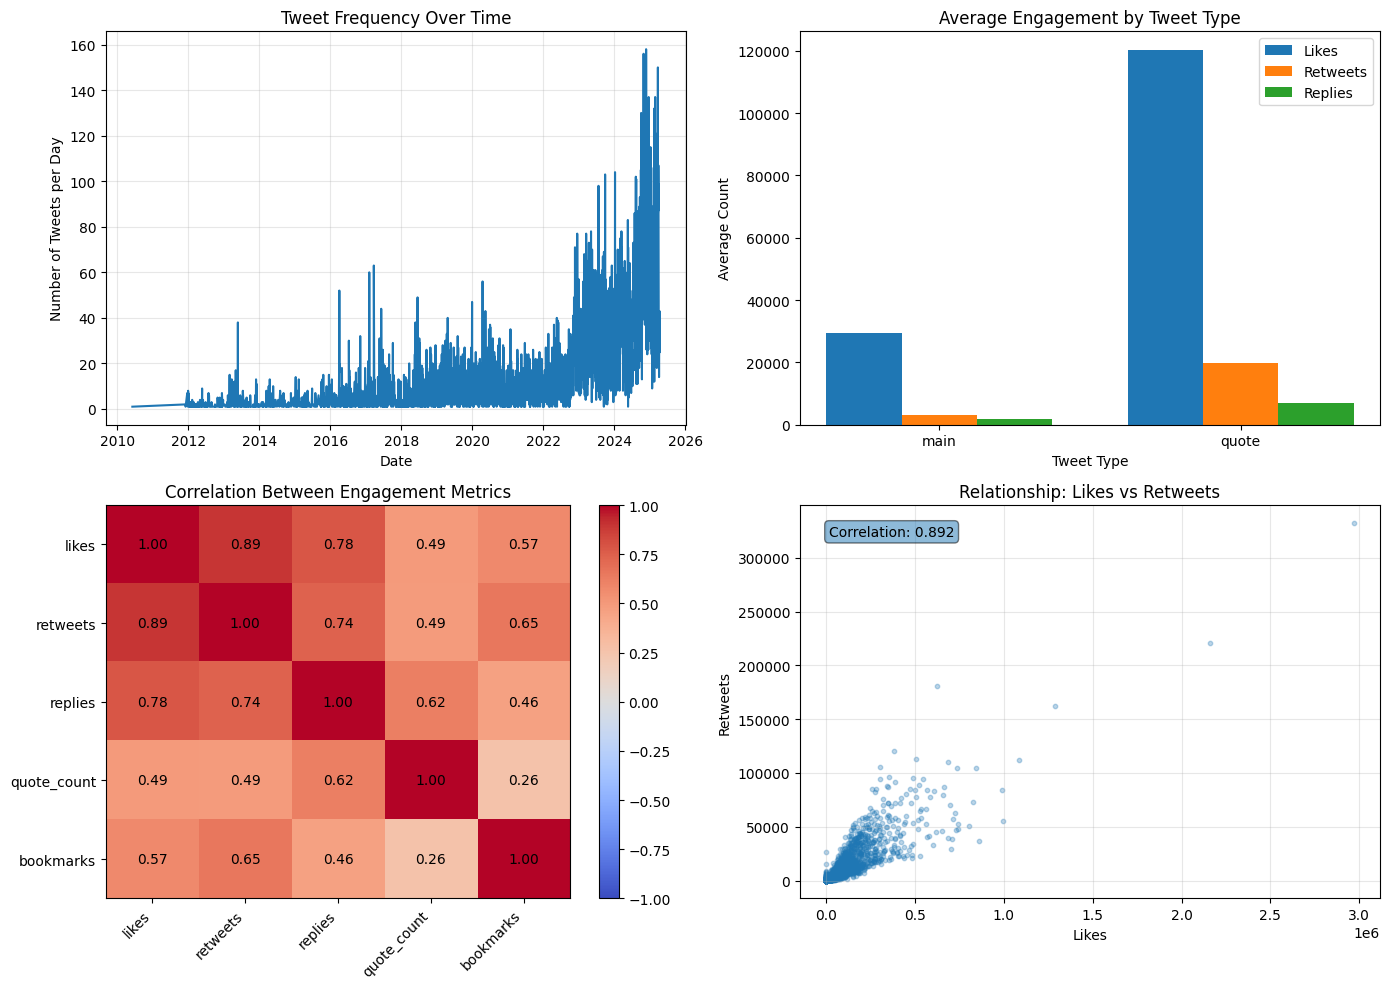

In [43]:
# Due to how heavily skewed the tweet engagement data is compared to normally distrubuted stock data, I will need different approaches when exploring their relationship.
# Relationship analysis between variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tweet frequency over time
tweets_by_date = all_tweets_combined.groupby('date_only').size().reset_index(name='tweet_count')
tweets_by_date['date_only'] = pd.to_datetime(tweets_by_date['date_only'])
tweets_by_date = tweets_by_date.sort_values('date_only')

axes[0, 0].plot(tweets_by_date['date_only'], tweets_by_date['tweet_count'])
axes[0, 0].set_title('Tweet Frequency Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Tweets per Day')
axes[0, 0].grid(True, alpha=0.3)

# Engagement by tweet type
engagement_by_type = all_tweets_combined.groupby('tweet_type')[['likes', 'retweets', 'replies']].mean()
x_pos = range(len(engagement_by_type.index))
width = 0.25

axes[0, 1].bar([p - width for p in x_pos], engagement_by_type['likes'], width, label='Likes')
axes[0, 1].bar(x_pos, engagement_by_type['retweets'], width, label='Retweets')
axes[0, 1].bar([p + width for p in x_pos], engagement_by_type['replies'], width, label='Replies')
axes[0, 1].set_title('Average Engagement by Tweet Type')
axes[0, 1].set_xlabel('Tweet Type')
axes[0, 1].set_ylabel('Average Count')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(engagement_by_type.index)
axes[0, 1].legend()

# Correlation between engagement metrics
engagement_corr = all_tweets_combined[['likes', 'retweets', 'replies', 'quote_count', 'bookmarks']].corr()
im = axes[1, 0].imshow(engagement_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(engagement_corr.columns)))
axes[1, 0].set_yticks(range(len(engagement_corr.columns)))
axes[1, 0].set_xticklabels(engagement_corr.columns, rotation=45, ha='right')
axes[1, 0].set_yticklabels(engagement_corr.columns)
axes[1, 0].set_title('Correlation Between Engagement Metrics')

# Add correlation values to heatmap
for i in range(len(engagement_corr)):
    for j in range(len(engagement_corr)):
        axes[1, 0].text(j, i, f'{engagement_corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.colorbar(im, ax=axes[1, 0])

# Scatter - Likes vs Retweets (relationship between engagement types)
sample_tweets = all_tweets_combined.dropna(subset=['likes', 'retweets']).sample(min(5000, len(all_tweets_combined)))
axes[1, 1].scatter(sample_tweets['likes'], sample_tweets['retweets'], alpha=0.3, s=10)
axes[1, 1].set_title('Relationship: Likes vs Retweets')
axes[1, 1].set_xlabel('Likes')
axes[1, 1].set_ylabel('Retweets')
axes[1, 1].grid(True, alpha=0.3)

# Add correlation coefficient
corr_coef = all_tweets_combined[['likes', 'retweets']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', transform=axes[1, 1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.5))

plt.tight_layout()
plt.show()


# Relationship Analysis

*   Tweet frequency trends - Elon's Twitter activity has increased A LOT over time. He used to tweet 5-10 times per day in 2010-2020, but now tweets over 100 times per day.
*   Tweet type engagement - Quote tweets outperform main tweets across the board. Quote tweets avg 120k likes vs 28k for main tweets, with similarly large gaps in retweets and replies. This tells me that Elon's engagement on other people's content generates more engagement than his own posts. This might be because quote tweets often involve reactions to controversial topics or industry news.
*   Engagement metric correlations - Strong positive correlations exist between all engagement metrics, with likes and retweets showing the highest correlation. This indicates tweets don't just get "liked" or "retweeted" by themselves, viral tweets are usually viral across all fields.
*   Likes vs retweets relationship - The scatter plot confirms the strong positive correlation between likes and retweets. This tight relationship suggests these metrics can potentially be combined into a composite "virality" score for analysis.

## Step 3:  Identify 1-3 research questions and perform analysis

Now that you have a better understanding of the data, you will want to form a research question which is interesting to you. The research question should be broad enough to be of interest to a reader but narrow enough that the question can be answered with the data.  Some examples:

* __Too Narrow:__  What is the GDP of the U.S. for 2011?  This is just asking for a fact or a single data point.  

* __Too Broad:__  What is the primary reason for global poverty?  This could be a Ph.D. thesis and would still be way too broad.  What data will you use to answer this question?  Even if a single dataset offered an answer, would it be defendable given the variety of datasets out there?

* __Good:__  Can you use simple sentiment analysis on comments about movies in a movie database to predict its box office earnings?  If you have, or can obtain, data on a variety of movies and you have their box office earnings, this is a question which you can potentially answer well.

__Remember__, this course is for learning Python. You will not be graded on the complexity, accuracy or performance of your analytical methods. However, you are expected to use a Python library, e.g., _scikitlearn_, successfully to generate results and explain why you picked the methods you used.



# Research questions
Do Elon Musk's controversial tweets correlate with Tesla stock price movements?

In [44]:
# Identify controversial/pump tweets using keywords

pump_keywords = [
    # Stock manipulation
    'funding secured', 'taking tesla private', 'take tesla private',
    'stock price is too high', 'stock price too high', 'stock too high',

    # Short seller attacks
    'short shorts', 'short burn', 'short squeeze', 'shorts will', 'shortseller',
    'short seller', 'shorter', 'burn the shorts',

    # Autonomy/FSD promises
    'robotaxi', 'robo-taxi', 'full self-driving', 'fsd', 'self-driving',
    'autonomous', 'autopilot', 'coast to coast',

    # Production/delivery hype
    'production target', 'delivery target', 'deliveries', 'production ramp',
    'ramping production', 'production hell', 'giga', 'gigafactory',

    # Profitability
    'gaap profitable', 'profitable', 'profitability', 'record profit',
    'record quarter', 'best quarter',

    #  hype
    'demand is', 'record demand', 'massive demand', 'insane demand', 'revolutionary', 'game changer', 'breakthrough'

    # Product announcements
    'coming soon', 'next year', 'cybertruck', 'roadster', 'model',
    'battery day', 'plaid',
]

# Function to check if tweet contains pump keywords
def is_pump_tweet(text):
    if pd.isna(text):
        return False
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in pump_keywords)

# Apply to all tweets
all_tweets_combined['is_controversial'] = all_tweets_combined['elon_text'].apply(is_pump_tweet)

# Summary
print(f"Total tweets: {len(all_tweets_combined)}")
print(f"Controversial tweets: {all_tweets_combined['is_controversial'].sum()}")
print(f"Percentage: {all_tweets_combined['is_controversial'].mean()*100:.1f}%")

Total tweets: 54960
Controversial tweets: 1739
Percentage: 3.2%


In [45]:
# Do controversial tweets correlate with bigger stock movements? (Only look at tweets on trading days (where we have next-day data))

trading_tweets = all_tweets_combined[all_tweets_combined['next_day_return'] != 0].copy()

controversial = trading_tweets[trading_tweets['is_controversial']]
normal = trading_tweets[trading_tweets['is_controversial'] == False]

print(f"\nControversial tweets ({len(controversial)}):")
print(f"  Avg same-day return: {controversial['daily_return'].mean():.2f}%")
print(f"  Avg next-day return: {controversial['next_day_return'].mean():.2f}%")

print(f"\nNormal tweets ({len(normal)}):")
print(f"  Avg same-day return: {normal['daily_return'].mean():.2f}%")
print(f"  Avg next-day return: {normal['next_day_return'].mean():.2f}%")



Controversial tweets (1214):
  Avg same-day return: 0.46%
  Avg next-day return: 0.20%

Normal tweets (37238):
  Avg same-day return: 0.09%
  Avg next-day return: 0.24%


In [46]:
# Statistical test to see if the difference is significant

controversial_returns = controversial['daily_return'].dropna()
normal_returns = normal['daily_return'].dropna()

# T-test
t_stat, p_value = stats.ttest_ind(controversial_returns, normal_returns)

print(f"T-stat: {t_stat:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05: print("The difference IS statistically significant (p < 0.05)")
else: print("The difference is NOT statistically significant (p >= 0.05)")

T-stat: 3.19
P-value: 0.00140
The difference IS statistically significant (p < 0.05)


In [47]:
# Robustness check - Analysis by Day instead of by tweet
# Addresses potential inflation from multiple tweets on same day

tweets_by_date = all_tweets_combined.groupby('date_only').agg({'is_controversial': 'any','daily_return': 'first','tweet_id': 'count'}).reset_index()

tweets_by_date.rename(columns={'tweet_id': 'tweet_count'}, inplace=True)

controversial_days = tweets_by_date[tweets_by_date['is_controversial']]
normal_days = tweets_by_date[~tweets_by_date['is_controversial']]

print(f"Days with controversial tweets: {len(controversial_days)}")
print(f" Avg return: {controversial_days['daily_return'].mean():.2f}%")

print(f"\nDays with only normal tweets: {len(normal_days)}")
print(f" Avg return: {normal_days['daily_return'].mean():.2f}%")

# Statistical test
t_stat, p_value = stats.ttest_ind(controversial_days['daily_return'].dropna(),normal_days['daily_return'].dropna())

print(f"\nT-stat: {t_stat:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05: print("The difference IS statistically significant (p < 0.05)")
else: print("The difference is NOT statistically significant (p >= 0.05)")

Days with controversial tweets: 1076
 Avg return: 0.41%

Days with only normal tweets: 2377
 Avg return: 0.19%

T-stat: 1.29
P-value: 0.19548
The difference is NOT statistically significant (p >= 0.05)


## Step 4:  Present your findings

In this step, you can begin to report your findings.  What did you learn from the data and how do your findings help answer your research question?  Use _matplotlib_ visualizations to present these findings.


__Remember:__ Rarely will a single data analysis conclusively answer a research question.  Here, you need to identify possible limitations.  For example, are your results limited to a certain area, city, or country?  Are you making assumptions about the data which may, or may not, be valid (e.g., that students in one term are equally qualified as students in another)?  Document these limitations in a few paragraphs.


Do Elon Musk's controversial tweets correlate with same day Tesla stock price movements?
Controversial tweets: 1214 tweets
 Avg. same day return: 0.46%
 Avg. next day return: 0.20%

Normal tweets: 37264 tweets
 Avg. same day return: 0.09%
 Avg. next day return: 0.24%

Difference: Controversial tweets move stock 5.2x more

Statistical significance: p = 0.0016
Result: SIGNIFICANT

Day Level Analysis - Takes into account multiple tweets/day
Days with controversial tweets: 1076
 Avg. same day return: 0.41%

Days with only normal tweets: 2377
 Avg. same day return: 0.19%

Difference: Controversial days show 2.1x larger returns

Statistical significance: p = 0.1955
Result: NOT SIGNIFICANT


/tmp/ipython-input-366747500.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([normal['daily_return'], controversial['daily_return']], labels=['Normal', 'Controversial'])


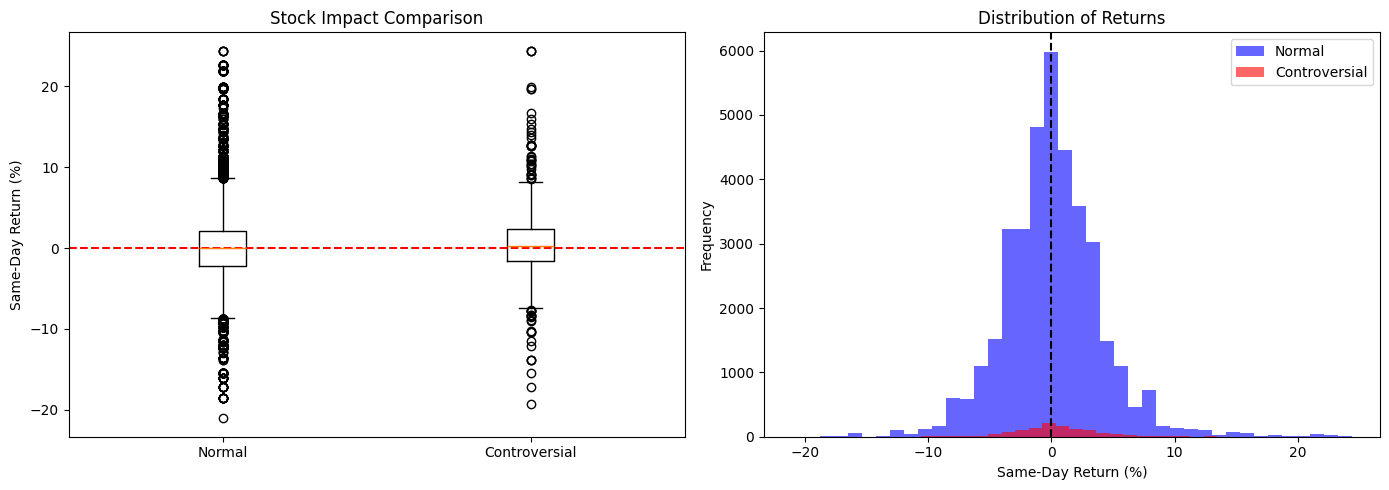


Example: 'Funding Secured' tweet had a 10.99% same-day return


In [48]:
#EXPAND THIS SECTION TO PRESENT YOUR FINDINGS

print("Do Elon Musk's controversial tweets correlate with same day Tesla stock price movements?")

# comparison of normal & controversial tweets
trading_tweets = all_tweets_combined[all_tweets_combined['daily_return'].notna()].copy()
controversial = trading_tweets[trading_tweets['is_controversial']]
normal = trading_tweets[trading_tweets['is_controversial'] == False]

print(f"Controversial tweets: {len(controversial)} tweets")
print(f" Avg. same day return: {controversial['daily_return'].mean():.2f}%")
print(f" Avg. next day return: {controversial['next_day_return'].mean():.2f}%")
print(f"\nNormal tweets: {len(normal)} tweets")
print(f" Avg. same day return: {normal['daily_return'].mean():.2f}%")
print(f" Avg. next day return: {normal['next_day_return'].mean():.2f}%")
print(f"\nDifference: Controversial tweets move stock {controversial['daily_return'].mean() / normal['daily_return'].mean():.1f}x more")

# Statistical test
t_stat, p_value = stats.ttest_ind(controversial['daily_return'].dropna(), normal['daily_return'].dropna())
print(f"\nStatistical significance: p = {p_value:.4f}")
print(f"Result: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'}")

# Day level check
controversial_days = tweets_by_date[tweets_by_date['is_controversial']]
normal_days = tweets_by_date[~tweets_by_date['is_controversial']]

print(f"\nDay Level Analysis - Takes into account multiple tweets/day")
print(f"Days with controversial tweets: {len(controversial_days)}")
print(f" Avg. same day return: {controversial_days['daily_return'].mean():.2f}%")
print(f"\nDays with only normal tweets: {len(normal_days)}")
print(f" Avg. same day return: {normal_days['daily_return'].mean():.2f}%")
print(f"\nDifference: Controversial days show {controversial_days['daily_return'].mean() / normal_days['daily_return'].mean():.1f}x larger returns")

t_stat_days, p_value_days = stats.ttest_ind(controversial_days['daily_return'].dropna(), normal_days['daily_return'].dropna())
print(f"\nStatistical significance: p = {p_value_days:.4f}")
print(f"Result: {'SIGNIFICANT' if p_value_days < 0.05 else 'NOT SIGNIFICANT'}")

#  plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison
axes[0].boxplot([normal['daily_return'], controversial['daily_return']], labels=['Normal', 'Controversial'])
axes[0].set_ylabel('Same-Day Return (%)')
axes[0].set_title('Stock Impact Comparison')
axes[0].axhline(y=0, color='red', linestyle='--')

# Distribution
axes[1].hist(normal['daily_return'], bins=40, alpha=0.6, label='Normal', color='blue')
axes[1].hist(controversial['daily_return'], bins=40, alpha=0.6, label='Controversial', color='red')
axes[1].set_xlabel('Same-Day Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Returns')
axes[1].legend()
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# Example case
funding = all_tweets_combined[all_tweets_combined['elon_text'].str.contains('funding secured', case=False, na=False)]
print(f"\nExample: 'Funding Secured' tweet had a {funding.iloc[0]['daily_return']:.2f}% same-day return")

In [49]:
# Final project phase 2: continued... Merge combined tweet DF/stock DF with news DF

# Convert news date field to match tweet/stock df
news_df['date_only'] = pd.to_datetime(news_df['published']).dt.strftime('%Y-%m-%d')

tweets_with_news = all_tweets_combined.merge(news_df[['date_only','title','summary']],
on='date_only', how='left')

print(f"Tweets with news articles: {tweets_with_news['title'].notna().sum()}")
tweets_with_news.head()

Tweets with news articles: 452542


,tweet_id,elon_text,retweets,replies,likes,quote_count,bookmarks,views,created_at,date_only,...,is_pinned,is_retweet,quoted_text,daily_return,DeltaDay,DeltaHighLow,next_day_return,is_controversial,title,summary
0,1911429071470293414,Starlink now in Somalia!,6310.0,4808.0,51382.0,691.0,1088.0,20256907.0,2025-04-13 14:39:37+00:00,2025-04-13,...,False,False,SOMALIA GRANTS STARLINK LICENSE TO OPERATE NAT...,NaN,0.0,0.0,0.0,False,Tesla’s vehicles led U.S. EV sales again last ...,"<p>Tesla, Ford, and Chevrolet's models led the..."
1,1911429071470293414,Starlink now in Somalia!,6310.0,4808.0,51382.0,691.0,1088.0,20256907.0,2025-04-13 14:39:37+00:00,2025-04-13,...,False,False,SOMALIA GRANTS STARLINK LICENSE TO OPERATE NAT...,NaN,0.0,0.0,0.0,False,These were the best-selling EV brands in the U...,<p>Tesla remained the clear market leader in Q...
2,1911425272953372813,RT @Tesla: No outages with Powerwall,948.0,437.0,5511.0,31.0,164.0,1973411.0,2025-04-13 14:24:32+00:00,2025-04-13,...,False,True,NaN,NaN,0.0,0.0,0.0,False,Tesla’s vehicles led U.S. EV sales again last ...,"<p>Tesla, Ford, and Chevrolet's models led the..."
3,1911425272953372813,RT @Tesla: No outages with Powerwall,948.0,437.0,5511.0,31.0,164.0,1973411.0,2025-04-13 14:24:32+00:00,2025-04-13,...,False,True,NaN,NaN,0.0,0.0,0.0,False,These were the best-selling EV brands in the U...,<p>Tesla remained the clear market leader in Q...
4,1911532025233723740,Worth reading the book 1493,1317.0,2731.0,15579.0,196.0,2233.0,3135481.0,2025-04-13 21:28:44+00:00,2025-04-13,...,False,False,NaN,NaN,0.0,0.0,0.0,False,Tesla’s vehicles led U.S. EV sales again last ...,"<p>Tesla, Ford, and Chevrolet's models led the..."


In [50]:
# Phase 2 continued - Controversial days with positive returns & news

# aggregate news by dates that had positive returns and positive news article sentiment
news_grouped = news_df.groupby('date_only').agg({'title': lambda x: ' | '.join(x), 'summary': lambda x: ' | '.join(x)}).reset_index()
news_grouped['article_count'] = news_df.groupby('date_only').size().values

#  Merge with day level analysis from robustness check
tweets_by_date_with_news = tweets_by_date.merge(news_grouped[['date_only', 'title', 'article_count']], on='date_only', how='left')

# filter for controversial days w/ positive returns
controversial_gain_days = tweets_by_date_with_news[(tweets_by_date_with_news['is_controversial'] == True) & (tweets_by_date_with_news['daily_return'] > 0)
& (tweets_by_date_with_news['title'].notna())]

print(f"Controversial days with positive returns & news: {len(controversial_gain_days)}")
print(f"Avg. return: {controversial_gain_days['daily_return'].mean():.2f}%")
print(f"Avg. articles/day: {controversial_gain_days['article_count'].mean():.1f}")

# Top 10 days
print("\nTop 10 Days by stock return:")
print(controversial_gain_days.nlargest(10, 'daily_return')[['daily_return', 'date_only', 'article_count', 'tweet_count']])

#Controversial days WITHOUT news
controversial_no_news_days = tweets_by_date_with_news[(tweets_by_date_with_news['is_controversial'] == True) & (tweets_by_date_with_news['title'].isna())]

print(f"\nControversial days with NO news: {len(controversial_no_news_days)}")
print(f"Avg. return: {controversial_no_news_days['daily_return'].mean():.2f}%")

Controversial days with positive returns & news: 372
Avg. return: 2.95%
Avg. articles/day: 8.8

Top 10 Days by stock return:
      daily_return   date_only  article_count  tweet_count
1620     19.894859  2020-02-03            7.0           16
1992     19.641208  2021-03-09           11.0            8
3103     15.306917  2024-04-29           21.0           45
3294     14.751032  2024-11-06            9.0           69
316      13.944401  2014-02-25            1.0            2
1683     13.603839  2020-04-13            7.0            7
1196     12.718905  2018-10-23            6.0            9
2214     12.661598  2021-10-25            8.0           17
1643     11.322034  2020-03-02            8.0           10
1802     11.203058  2020-08-17           10.0           18

Controversial days with NO news: 80
Avg. return: 1.55%


In [51]:
# Sentiment analysis on news articles
sentiment_pipeline = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english")

def get_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_pipeline(text[:512])[0]
    label = result['label']
    score = result['score']
    if label == 'NEGATIVE':
        score = -score
    return score, label

# Apply to news titles
news_df[['title_sentiment', 'title_label']] = news_df['title'].apply(lambda x: pd.Series(get_sentiment(x)))

# Agg. by day
news_sentiment = news_df.groupby('date_only').agg({'title_sentiment': 'mean', 'title': 'count'}).reset_index()
news_sentiment.rename(columns={'title': 'article_count'}, inplace=True)

# Add label aggregation
news_labels = news_df.groupby('date_only')['title_label'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None).reset_index()
news_labels.rename(columns={'title_label': 'dominant_label'}, inplace=True)
news_sentiment = news_sentiment.merge(news_labels, on='date_only', how='left')

# Merge with controversial gain days
controversial_gain_days_sentiment = controversial_gain_days.merge(news_sentiment[['date_only', 'title_sentiment', 'dominant_label']], on='date_only', how='left')

print(f"Controversial days with positive returns & news: {len(controversial_gain_days_sentiment)}")
print(f"Avg. sentiment on controversial gain days: {controversial_gain_days_sentiment['title_sentiment'].mean():.3f}")
print("\nTop 10 days with sentiment:")
print(controversial_gain_days_sentiment.nlargest(10, 'daily_return')[['daily_return', 'date_only', 'title_sentiment', 'dominant_label', 'article_count']])

correlation = controversial_gain_days_sentiment[['title_sentiment', 'daily_return']].corr().iloc[0,1]
print(f"\nCorrelation between news sentiment & stock return: {correlation:.3f}")

Device set to use cuda:0


Controversial days with positive returns & news: 372
Avg. sentiment on controversial gain days: 0.545

Top 10 days with sentiment:
     daily_return   date_only  title_sentiment dominant_label  article_count
139     19.894859  2020-02-03         0.712636       POSITIVE            7.0
200     19.641208  2021-03-09         0.634934       POSITIVE           11.0
329     15.306917  2024-04-29         0.521824       POSITIVE           21.0
357     14.751032  2024-11-06         0.779175       POSITIVE            9.0
2       13.944401  2014-02-25         0.998226       POSITIVE            1.0
149     13.603839  2020-04-13         0.707839       POSITIVE            7.0
90      12.718905  2018-10-23         0.997152       POSITIVE            6.0
230     12.661598  2021-10-25         0.752555       POSITIVE            8.0
142     11.322034  2020-03-02         0.747740       POSITIVE            8.0
169     11.203058  2020-08-17         0.795773       POSITIVE           10.0

Correlation between n

In [52]:
# Analyze controversial days with NEGATIVE returns
controversial_loss_days = tweets_by_date_with_news[(tweets_by_date_with_news['is_controversial'] == True) & (tweets_by_date_with_news['daily_return'] < 0) &(tweets_by_date_with_news['title'].notna())]

# Merge sentiment
controversial_loss_days_sentiment = controversial_loss_days.merge(news_sentiment[['date_only', 'title_sentiment', 'dominant_label']],on='date_only',how='left')

print("\nControversial Days with NEGATIVE Returns")
print(f"Controversial days with negative returns & news: {len(controversial_loss_days_sentiment)}")
print(f"Avg. return: {controversial_loss_days_sentiment['daily_return'].mean():.2f}%")
print(f"Avg. sentiment: {controversial_loss_days_sentiment['title_sentiment'].mean():.3f}")
print(f"Avg. articles/day: {controversial_loss_days_sentiment['article_count'].mean():.1f}")

print("\nTop 10 Worst Days by stock return:")
print(controversial_loss_days_sentiment.nsmallest(10, 'daily_return')[['daily_return', 'date_only', 'title_sentiment', 'dominant_label', 'article_count']])

correlation_neg = controversial_loss_days_sentiment[['title_sentiment', 'daily_return']].corr().iloc[0,1]
print(f"\nCorrelation between sentiment & negative returns: {correlation_neg:.3f}")

print("\nCOMPARISON")
print(f"Positive return days: sentiment = {controversial_gain_days_sentiment['title_sentiment'].mean():.3f}")
print(f"Negative return days: sentiment = {controversial_loss_days_sentiment['title_sentiment'].mean():.3f}")


Controversial Days with NEGATIVE Returns
Controversial days with negative returns & news: 341
Avg. return: -2.52%
Avg. sentiment: 0.497
Avg. articles/day: 8.8

Top 10 Worst Days by stock return:
     daily_return   date_only  title_sentiment dominant_label  article_count
130    -17.175839  2020-02-05         0.633816       POSITIVE           11.0
332    -15.426207  2025-03-10        -0.496642       NEGATIVE            8.0
72     -13.901537  2018-09-28         0.498081       POSITIVE            4.0
278    -12.125293  2024-01-25         0.633776       POSITIVE           11.0
198    -11.554176  2022-01-27         0.552750       POSITIVE            9.0
337    -10.419787  2025-04-04         0.332401       POSITIVE            3.0
147    -10.341091  2020-09-23         0.333347       POSITIVE            9.0
134    -10.303371  2020-05-01         0.712672       POSITIVE            7.0
146     -9.023849  2020-09-03         0.816538       POSITIVE           11.0
234     -8.882757  2022-12-22     

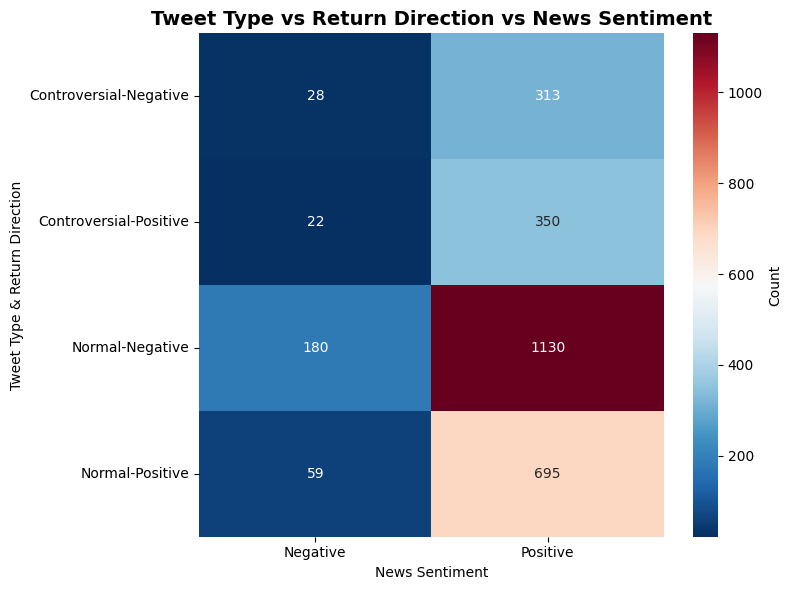

In [53]:
# Create heatmap comparing tweet type, return direction, and sentiment

# Combine positive and negative day data
all_days_sentiment = pd.concat([controversial_gain_days_sentiment[['date_only', 'daily_return', 'title_sentiment', 'is_controversial']],
    controversial_loss_days_sentiment[['date_only', 'daily_return', 'title_sentiment', 'is_controversial']]])

# Add normal days with news
normal_days_with_news = tweets_by_date_with_news[(tweets_by_date_with_news['is_controversial'] == False) &(tweets_by_date_with_news['title'].notna())]
normal_days_sentiment = normal_days_with_news.merge(news_sentiment[['date_only', 'title_sentiment']], on='date_only', how='left')
normal_days_sentiment['is_controversial'] = False

# Combine all
all_combined = pd.concat([all_days_sentiment, normal_days_sentiment[['date_only', 'daily_return', 'title_sentiment', 'is_controversial']]])

# Create categories
all_combined['tweet_type'] = all_combined['is_controversial'].map({True: 'Controversial', False: 'Normal'})
all_combined['return_direction'] = all_combined['daily_return'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
all_combined['sentiment_label'] = all_combined['title_sentiment'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Create pivot table for heatmap
heatmap_data = all_combined.groupby(['tweet_type', 'return_direction', 'sentiment_label']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot_table(values='count',index=['tweet_type', 'return_direction'],columns='sentiment_label',fill_value=0)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt='g', cmap='RdBu_r', cbar_kws={'label': 'Count'})
plt.title('Tweet Type vs Return Direction vs News Sentiment', fontweight='bold', fontsize=14)
plt.xlabel('News Sentiment')
plt.ylabel('Tweet Type & Return Direction')
plt.tight_layout()
plt.show()

## Phase 2 Findings: News Sentiment Analysis

Using RoBERTa sentiment analysis on news headlines, I examined whether media sentiment correlates with stock returns on controversial tweet days.

**Key Findings:**

Days with controversial tweets & positive returns showed moderately positive news sentiment (0.545 average), while days with negative returns showed slightly less positive sentiment (0.497 average). This difference translates to very little predictive insight, with correlations of only 0.099 and 0.082 respectively.

9 out of 10 of days with the largest % decrease in stock movement still had positive headlines, including the -17% decline on Feb 5, 2020 (0.634 sentiment). Only one crash day (Mar 10, 2025: -15.4% return) showed negative sentiment (-0.497). On the other hand, all top 10 gain days featured positive headlines, with the highest sentiment (0.998) not necessarily corresponding to the largest gains.

**Conclusion:**

News coverage about Tesla usually has a consistently positive tone (averaging 0.52 across all controversial days) regardless of actual stock performance. The weak correlation suggests sentiment has limited predictive value for stock movement. As identified in earlier analysis, media attention volume (8.8 articles/day average) appears more predictive than sentiment tone. Days with both controversial tweets and substantial news coverage saw the largest movements (2.95% average return vs 1.55% for controversial days without news), indicating that visibility and trading volume matter more than whether coverage is glowing or merely positive.

## Limitations

While the analysis reveals insights about the relationship between controversial tweets and stock returns, several important limitations emerged:

1. **Causation vs Correlation**: This analysis shows correlation but cannot prove that tweets cause stock movements. The robustness check revealed that when controlling for multiple tweets per day, the statistical significance disappears (p = 0.195), suggesting other factors like earnings reports, market conditions, or news coverage may be the primary drivers of stock movements on controversial tweet days.

2. **Multiple Tweets Inflation**: The initial finding of 4.6x larger returns (p = 0.0016) was based on tweet level analysis, where days with many tweets were counted multiple times. Day level analysis showed a more modest 2.2x effect that was not statistically significant, indicating the original effect size was inflated.

3. **News Coverage**: Phase 2 analysis revealed that controversial tweet days with substantial news coverage (averaging 8.8 articles/day) showed 2.95% returns, while controversial days without news showed only 1.55% returns. This suggests media attention may be a stronger driver than tweet content itself.

4. **Timing Issues**: Daily returns cannot capture the precise timing of tweet impact. Tweets posted after market close would not affect same day prices, a more in depth analysis using exact timestamps might lead to more accurate results.

5. **Keyword Limitations**: The controversy classification relies on predefined keywords that may miss some controversial content or incorrectly flag non controversial tweets. Manual review shows the method captures major controversial topics but it's not perfect.

6. **Sentiment Limitations**: News sentiment analysis showed consistently positive coverage (0.52 average) regardless of stock direction, with weak correlations (0.099). Even major crash days featured positive headlines, indicating sentiment analysis has limited predictive value.

7. **External Validation**: These findings are specific to Tesla and Elon Musk during 2010-2025. The relationship between CEO social media activity and stock prices may not generalize to other companies or executives.

Despite these limitations, the analysis demonstrates that controversial tweet days correlate with elevated stock returns at the tweet level (0.41% vs 0.09%), though this effect diminishes and loses statistical significance when accounting for multiple tweets/day and appears partially driven by news coverage on those days rather than just the tweets by themselves.